# Activation Space vs. Behavior Space: Llama-3.1-8B Base Model Demo

> Exact reproduction of Goodfire's methodology (arXiv:2605.05115).
> Uses the BASE model (not instruct) — same as Goodfire's Llama 3.1 8B.
> Section 5 directly tests Max Ma's "local isometry / crack" claims.

**Model:** meta-llama/Meta-Llama-3.1-8B (float16, MPS) — BASE model, no chat template
**Layer:** 28 of 32 (Goodfire §2.2: "activations from layer 28")
**Prompts:** "What day is k days after z? Answer:" — base model completes directly to day token
**Distance:** Cubic spline arc length (Goodfire §2.3)
**PCA:** 64D (Goodfire §2.2)

**Prerequisites:** HuggingFace account + accepted Llama-3 license.
Run `huggingface-cli login` before starting.

In [1]:
import warnings
from itertools import combinations
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from scipy.interpolate import CubicSpline
import torch
from transformers import LlamaForCausalLM, AutoTokenizer

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

DAYS   = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
LAYER    = 28
PCA_DIMS = 64
print(f"Layer: {LAYER}, PCA dims: {PCA_DIMS}")

Device: mps
Layer: 28, PCA dims: 64


## Section 1: What Is Approximate Isometry? (Synthetic)

Establishes what "approximate isometry" means geometrically before loading any model.

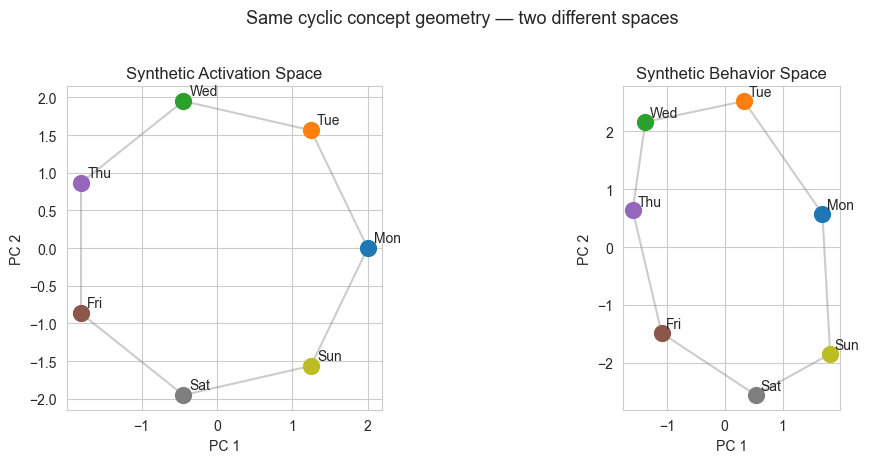

In [2]:
np.random.seed(42)
N = 7
short_labels = [d[:3] for d in DAYS]
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False)
act_synth = np.column_stack([np.cos(angles), np.sin(angles)]) * 2.0

A         = np.array([[0.8, -0.5], [0.3, 1.2]])
beh_synth = (A @ act_synth.T).T + np.random.randn(N, 2) * 0.18
colors_synth = [plt.cm.tab10(i / N) for i in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title in [
    (axes[0], act_synth, "Synthetic Activation Space"),
    (axes[1], beh_synth, "Synthetic Behavior Space"),
]:
    for i in range(N):
        ax.scatter(*data[i], color=colors_synth[i], s=130, zorder=3)
        ax.annotate(short_labels[i], data[i] + np.array([0.08, 0.08]), fontsize=10)
    for i in range(N):
        j = (i + 1) % N
        ax.plot([data[i,0], data[j,0]], [data[i,1], data[j,1]], color="gray", alpha=0.4, lw=1.5)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.suptitle("Same cyclic concept geometry — two different spaces", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

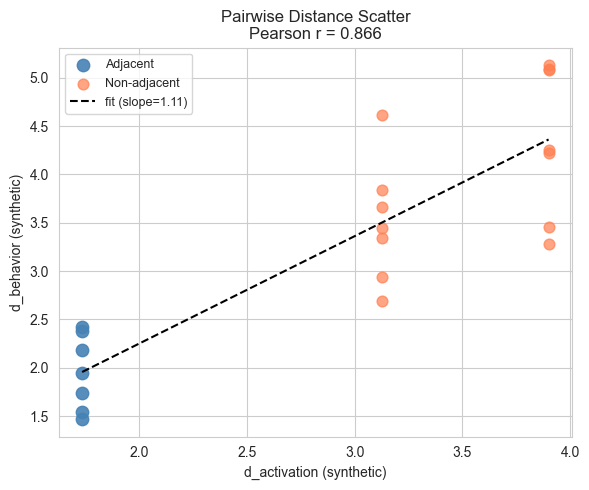

Synthetic r = 0.8660


In [3]:
pair_idxs   = list(combinations(range(N), 2))
d_act_synth = np.array([np.linalg.norm(act_synth[i]-act_synth[j]) for i,j in pair_idxs])
d_beh_synth = np.array([np.linalg.norm(beh_synth[i]-beh_synth[j]) for i,j in pair_idxs])
adj_synth   = np.array([abs(i-j)==1 or abs(i-j)==N-1 for i,j in pair_idxs])

r_synth, _ = pearsonr(d_act_synth, d_beh_synth)
m_synth     = np.polyfit(d_act_synth, d_beh_synth, 1)
x_line      = np.linspace(d_act_synth.min(), d_act_synth.max(), 100)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(d_act_synth[adj_synth],  d_beh_synth[adj_synth],  color="steelblue", s=80, alpha=0.9, label="Adjacent")
ax.scatter(d_act_synth[~adj_synth], d_beh_synth[~adj_synth], color="coral",     s=60, alpha=0.7, label="Non-adjacent")
ax.plot(x_line, np.polyval(m_synth, x_line), "k--", lw=1.5, label=f"fit (slope={m_synth[0]:.2f})")
ax.set_xlabel("d_activation (synthetic)"); ax.set_ylabel("d_behavior (synthetic)")
ax.set_title(f"Pairwise Distance Scatter\nPearson r = {r_synth:.3f}", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Synthetic r = {r_synth:.4f}")

## Section 2: Activation Space (Layer 28, Goodfire-Style Prompts)

**Prompt format (Goodfire §2.1):** "What day is k days after z? Answer:"
BASE model token-completes directly to the day name — no chat template needed.
High probability mass on the target day token creates sharp behavior-space geometry.

**Layer 28 (Goodfire §2.2):** Pre-final-norm residual stream. Carries cleaner
concept geometry than the final layer (which is distorted by the unembedding task).

**64D PCA (Goodfire §2.2):** Captures ~99.8% variance vs. ~86% at 10D.

In [4]:
MODEL_ID = "meta-llama/Meta-Llama-3.1-8B"
print(f"Loading {MODEL_ID} (BASE model) in float16 on {device}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = LlamaForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
model     = model.to(device)
model.train(False)
print(f"Loaded. Layers: {model.config.num_hidden_layers}, Hidden: {model.config.hidden_size}, Vocab: {model.config.vocab_size}")

Loading meta-llama/Meta-Llama-3.1-8B (BASE model) in float16 on mps...


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Loaded. Layers: 32, Hidden: 4096, Vocab: 128256


In [5]:
def goodfire_day_prompts(target_day: str, n: int = 15) -> list[str]:
    """
    Goodfire §2.1: 'What day is k days after z? Answer:'
    BASE model completes directly to the target day token.
    For each k, source = (target - k) mod 7, so answer is always target_day.
    """
    target_idx = DAYS.index(target_day)
    prompts = []
    for k in range(1, n + 1):
        source_idx = (target_idx - k) % 7
        source_day = DAYS[source_idx]
        day_word   = "day" if k == 1 else "days"
        prompts.append(f"What day is {k} {day_word} after {source_day}? Answer:")
    return prompts

def goodfire_month_prompts(target_month: str, n: int = 15) -> list[str]:
    """Same structure as day prompts but for months (Goodfire also tests months, r=0.89)."""
    target_idx = MONTHS.index(target_month)
    prompts = []
    for k in range(1, n + 1):
        source_idx  = (target_idx - k) % 12
        source_month = MONTHS[source_idx]
        month_word  = "month" if k == 1 else "months"
        prompts.append(f"What month is {k} {month_word} after {source_month}? Answer:")
    return prompts

DAY_PROMPTS   = {day:   goodfire_day_prompts(day,   n=15) for day in DAYS}
MONTH_PROMPTS = {month: goodfire_month_prompts(month, n=15) for month in MONTHS}

# Verify: top token for a day prompt should be the target day
print("Prompt sample (no chat template):")
print(f"  {DAY_PROMPTS['Monday'][0]!r}  → expected: 'Monday'")
print(f"  {DAY_PROMPTS['Friday'][2]!r}  → expected: 'Friday'")
print(f"Total day prompts: {sum(len(v) for v in DAY_PROMPTS.values())}")
print(f"Total month prompts: {sum(len(v) for v in MONTH_PROMPTS.values())}")

Prompt sample (no chat template):
  'What day is 1 day after Sunday? Answer:'  → expected: 'Monday'
  'What day is 3 days after Tuesday? Answer:'  → expected: 'Friday'
Total day prompts: 105
Total month prompts: 180


In [6]:
def get_hidden_state(prompt: str) -> np.ndarray:
    """Hidden state at LAYER, last token position. Shape: (4096,)"""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return outputs.hidden_states[LAYER][0, -1, :].cpu().numpy()

def get_probs(prompt: str) -> np.ndarray:
    """Softmax output distribution. Shape: (128256,)"""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.softmax(outputs.logits[0, -1, :], dim=-1).cpu().numpy()

def get_steered_probs(prompt: str, direction: np.ndarray, alpha: float) -> np.ndarray:
    """
    Steer at layer LAYER-1 (0-indexed). In transformers 5.x, LlamaDecoderLayer
    returns hidden_states as a plain Tensor — hook returns modified tensor directly.
    """
    inputs     = tokenizer(prompt, return_tensors="pt").to(device)
    dir_tensor = torch.tensor(direction, dtype=torch.float16).to(device)

    def hook_fn(module, input, output):
        return output + alpha * dir_tensor.reshape(1, 1, -1)

    handle = model.model.layers[LAYER - 1].register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.softmax(outputs.logits[0, -1, :], dim=-1).cpu().numpy()
    finally:
        handle.remove()
    return probs

def spline_arc_distances(centroids_nd: dict, concept_order: list, n_samples: int = 1000) -> np.ndarray:
    """
    Fit periodic cubic spline through ordered concept centroids.
    Returns (N, N) symmetric matrix of cyclic geodesic arc-length distances.
    """
    N   = len(concept_order)
    pts = np.array([centroids_nd[c] for c in concept_order])
    t   = np.arange(N + 1, dtype=float)
    pts_closed = np.vstack([pts, pts[0:1]])
    cs  = CubicSpline(t, pts_closed, bc_type="periodic")

    t_dense   = np.linspace(0, N, n_samples)
    pts_dense = cs(t_dense)
    seg_lens  = np.sqrt(((np.diff(pts_dense, axis=0))**2).sum(axis=1))
    cum_len   = np.concatenate([[0], np.cumsum(seg_lens)])
    total_len = cum_len[-1]

    concept_pos = []
    for i in range(N):
        idx = np.searchsorted(t_dense, float(i))
        concept_pos.append(cum_len[min(idx, len(cum_len) - 1)])

    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i == j: continue
            fwd = concept_pos[j] - concept_pos[i] if concept_pos[j] >= concept_pos[i] \
                  else total_len - concept_pos[i] + concept_pos[j]
            dist[i, j] = min(fwd, total_len - fwd)
    return dist

# Sanity check
test_prompt = DAY_PROMPTS["Monday"][0]
max_diff = np.abs(get_steered_probs(test_prompt, np.zeros(4096), 0.0) - get_probs(test_prompt)).max()
print(f"Hook sanity check (alpha=0): max prob diff = {max_diff:.2e}  (should be 0.0)")

# Confirm base model completes to day tokens
for day in ["Monday", "Friday", "Wednesday"]:
    p = get_probs(DAY_PROMPTS[day][0])
    top3 = [(tokenizer.decode([i]).strip(), float(p[i])) for i in np.argsort(p)[::-1][:3]]
    print(f"  Top tokens for {day!r} prompt: {top3}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Hook sanity check (alpha=0): max prob diff = 0.00e+00  (should be 0.0)
  Top tokens for 'Monday' prompt: [('Monday', 0.81103515625), ('', 0.025665283203125), ('The', 0.02410888671875)]


  Top tokens for 'Friday' prompt: [('Friday', 0.8095703125), ('', 0.030426025390625), ('Saturday', 0.0205841064453125)]
  Top tokens for 'Wednesday' prompt: [('Wednesday', 0.806640625), ('', 0.0225372314453125), ('It', 0.01477813720703125)]


Extracting day hidden states at layer 28 (105 prompts)...


Collected: (105, 4096)
PCA done. Explained variance (64 PCs): 98.6%

Layer sweep...


  Layer  1: r = 0.5091


  Layer  4: r = 0.3478


  Layer  8: r = 0.3827


...

  Layer 20: r = 0.6782


  Layer 24: r = 0.7279


  Layer 28: r = 0.8540


  Layer 30: r = 0.8112


  Layer 32: r = 0.8250


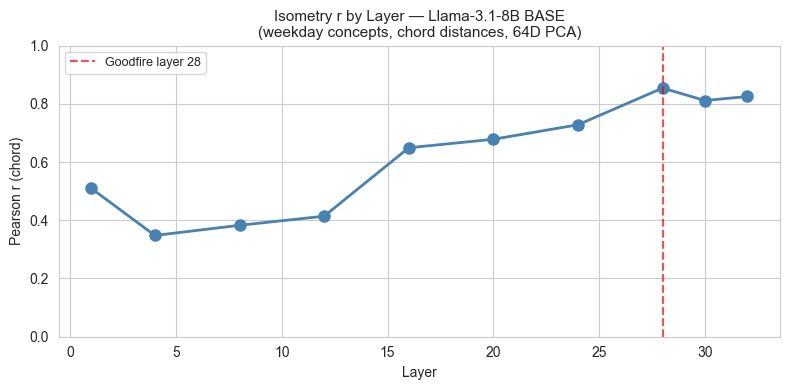


Best layer: 28 (r=0.8540),  Layer 28: r=0.8540


In [7]:
print(f"Extracting day hidden states at layer {LAYER} (105 prompts)...")
hidden_vectors, hidden_labels = [], []
for day in DAYS:
    for prompt in DAY_PROMPTS[day]:
        hidden_vectors.append(get_hidden_state(prompt))
        hidden_labels.append(day)

hidden_vectors = np.array(hidden_vectors)
hidden_labels  = np.array(hidden_labels)
print(f"Collected: {hidden_vectors.shape}")

pca_act    = PCA(n_components=PCA_DIMS, random_state=42)
pca_act_2d = PCA(n_components=2, random_state=42)
act_nd = pca_act.fit_transform(hidden_vectors)
act_2d = pca_act_2d.fit_transform(hidden_vectors)

act_centroids_nd = {day: act_nd[hidden_labels == day].mean(axis=0) for day in DAYS}
act_centroids_2d = {day: act_2d[hidden_labels == day].mean(axis=0) for day in DAYS}
print(f"PCA done. Explained variance ({PCA_DIMS} PCs): {pca_act.explained_variance_ratio_.sum():.1%}")

# Layer sweep
sweep_layers = [1, 4, 8, 12, 16, 20, 24, 28, 30, 32]
labels_sweep = np.array([d for d in DAYS for _ in range(15)])
print("\nLayer sweep...")
sweep_r = []
for layer in sweep_layers:
    acts, probs = [], []
    for day in DAYS:
        for prompt in DAY_PROMPTS[day]:
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            with torch.no_grad():
                out = model(**inputs, output_hidden_states=True)
            acts.append(out.hidden_states[layer][0, -1, :].cpu().numpy())
            probs.append(torch.softmax(out.logits[0, -1, :], dim=-1).cpu().numpy())
    acts  = np.array(acts)
    hell  = np.sqrt(np.array(probs))
    pa = PCA(n_components=min(PCA_DIMS, len(acts)-1), random_state=42).fit_transform(acts)
    pb = PCA(n_components=min(PCA_DIMS, len(acts)-1), random_state=42).fit_transform(hell)
    ca = {d: pa[labels_sweep == d].mean(axis=0) for d in DAYS}
    cb = {d: pb[labels_sweep == d].mean(axis=0) for d in DAYS}
    pairs_sw = list(combinations(DAYS, 2))
    da = np.array([euclidean(ca[d1], ca[d2]) for d1, d2 in pairs_sw])
    db = np.array([euclidean(cb[d1], cb[d2]) for d1, d2 in pairs_sw])
    r, _ = pearsonr(da, db)
    sweep_r.append(r)
    print(f"  Layer {layer:2d}: r = {r:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_layers, sweep_r, "o-", color="steelblue", lw=2, ms=8)
ax.axvline(LAYER, color="red", ls="--", alpha=0.7, label=f"Goodfire layer {LAYER}")
ax.set_xlabel("Layer"); ax.set_ylabel("Pearson r (chord)")
ax.set_title(f"Isometry r by Layer — Llama-3.1-8B BASE\n(weekday concepts, chord distances, {PCA_DIMS}D PCA)", fontsize=11)
ax.set_ylim(0, 1); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"\nBest layer: {sweep_layers[int(np.argmax(sweep_r))]} (r={max(sweep_r):.4f}),  Layer {LAYER}: r={sweep_r[sweep_layers.index(LAYER)]:.4f}")

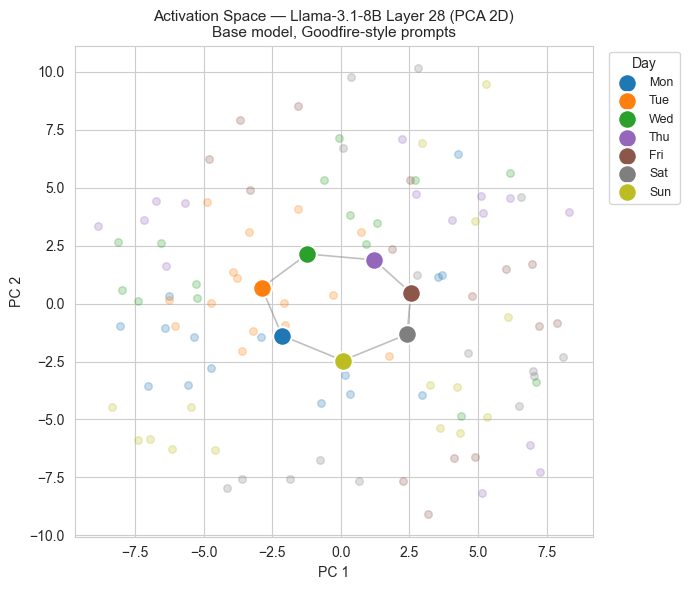

In [8]:
colors_map = {day: plt.cm.tab10(i / len(DAYS)) for i, day in enumerate(DAYS)}
short      = {d: d[:3] for d in DAYS}

fig, ax = plt.subplots(figsize=(7, 6))
for day in DAYS:
    mask = hidden_labels == day
    ax.scatter(act_2d[mask, 0], act_2d[mask, 1], color=colors_map[day], alpha=0.25, s=30)
for day in DAYS:
    ax.scatter(*act_centroids_2d[day], color=colors_map[day], s=180, zorder=4,
               edgecolors="white", linewidths=1.5, label=short[day])
for i in range(len(DAYS)):
    j = (i + 1) % len(DAYS)
    c1, c2 = act_centroids_2d[DAYS[i]], act_centroids_2d[DAYS[j]]
    ax.plot([c1[0], c2[0]], [c1[1], c2[1]], color="gray", lw=1.2, alpha=0.5)
ax.set_title(f"Activation Space — Llama-3.1-8B Layer {LAYER} (PCA 2D)\nBase model, Goodfire-style prompts", fontsize=11)
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(title="Day", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Section 3: Behavior Space + Isometry Plot

Goodfire §2.3: cubic spline through concept centroids, arc-length distances.
Base model should put high probability mass directly on day-name tokens.
Target: reproduce Goodfire's r = 0.99 for weekdays.

In [9]:
print("Extracting output probabilities (105 prompts)...")
prob_vectors, prob_labels = [], []
for day in DAYS:
    for prompt in DAY_PROMPTS[day]:
        prob_vectors.append(get_probs(prompt))
        prob_labels.append(day)

prob_vectors = np.array(prob_vectors)
prob_labels  = np.array(prob_labels)
hell_vectors = np.sqrt(prob_vectors)

print(f"Prob vectors: {prob_vectors.shape},  Hellinger norm check: {np.linalg.norm(hell_vectors[0]):.6f}")
for day in ["Monday", "Friday", "Saturday"]:
    p = get_probs(DAY_PROMPTS[day][0])
    top5 = [(tokenizer.decode([i]).strip(), f"{p[i]:.3f}") for i in np.argsort(p)[::-1][:5]]
    print(f"  Top tokens for {day!r}: {top5}")

Extracting output probabilities (105 prompts)...


Prob vectors: (105, 128256),  Hellinger norm check: 0.999512
  Top tokens for 'Monday': [('Monday', '0.811'), ('', '0.026'), ('The', '0.024'), ('It', '0.021'), ('Tuesday', '0.014')]


  Top tokens for 'Friday': [('Friday', '0.810'), ('', '0.030'), ('Saturday', '0.021'), ('It', '0.020'), ('The', '0.014')]
  Top tokens for 'Saturday': [('Saturday', '0.803'), ('', '0.022'), ('It', '0.020'), ('The', '0.018'), ('Sunday', '0.015')]


In [10]:
pca_beh    = PCA(n_components=PCA_DIMS, random_state=42)
pca_beh_2d = PCA(n_components=2, random_state=42)
beh_nd = pca_beh.fit_transform(hell_vectors)
beh_2d = pca_beh_2d.fit_transform(hell_vectors)

beh_centroids_nd = {day: beh_nd[prob_labels == day].mean(axis=0) for day in DAYS}
beh_centroids_2d = {day: beh_2d[prob_labels == day].mean(axis=0) for day in DAYS}
print(f"Explained variance ({PCA_DIMS} PCs, behavior): {pca_beh.explained_variance_ratio_.sum():.1%}")

Explained variance (64 PCs, behavior): 100.0%


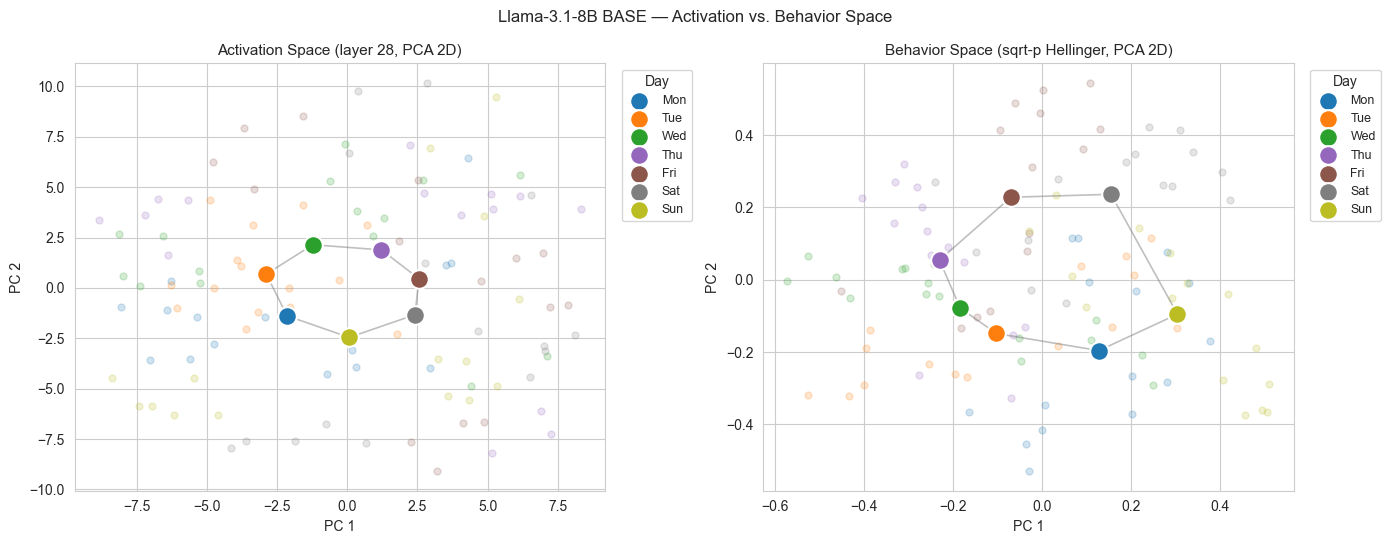

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, centroids_2d, all_2d, labels_arr, title in [
    (axes[0], act_centroids_2d, act_2d, hidden_labels, f"Activation Space (layer {LAYER}, PCA 2D)"),
    (axes[1], beh_centroids_2d, beh_2d, prob_labels,   "Behavior Space (sqrt-p Hellinger, PCA 2D)"),
]:
    for day in DAYS:
        mask = labels_arr == day
        ax.scatter(all_2d[mask, 0], all_2d[mask, 1], color=colors_map[day], alpha=0.2, s=25)
    for day in DAYS:
        ax.scatter(*centroids_2d[day], color=colors_map[day], s=180, zorder=4,
                   edgecolors="white", linewidths=1.5, label=short[day])
    for i in range(len(DAYS)):
        j = (i + 1) % len(DAYS)
        c1, c2 = centroids_2d[DAYS[i]], centroids_2d[DAYS[j]]
        ax.plot([c1[0], c2[0]], [c1[1], c2[1]], color="gray", lw=1.2, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(title="Day", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.suptitle("Llama-3.1-8B BASE — Activation vs. Behavior Space", fontsize=12)
plt.tight_layout()
plt.show()

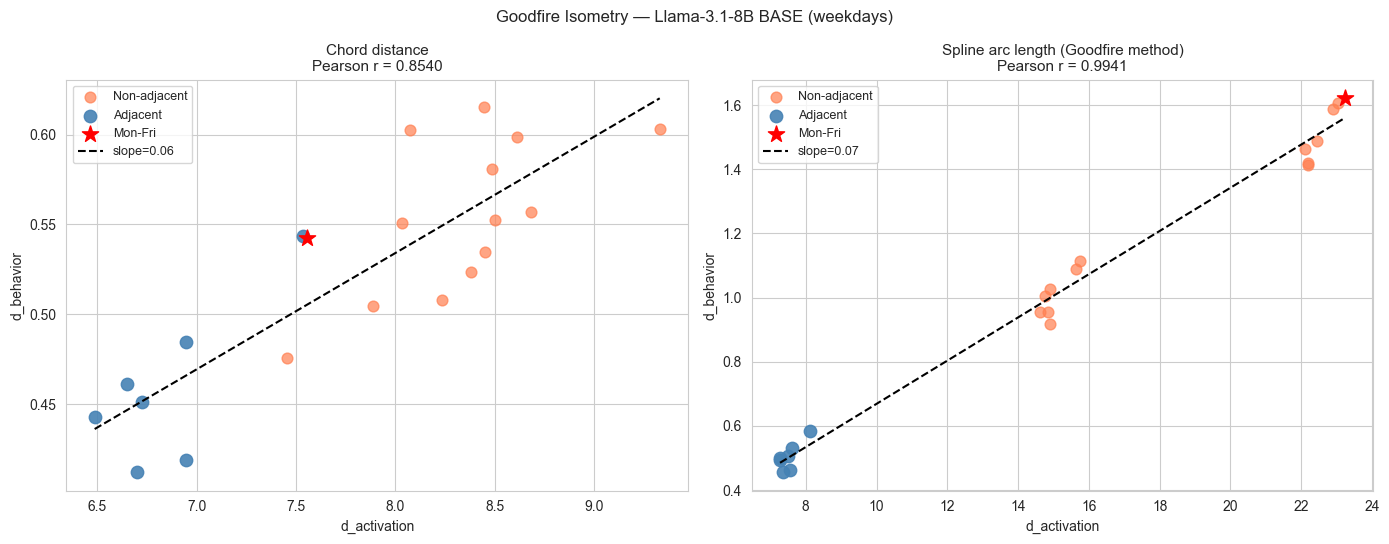

Chord r = 0.8540  |  Spline arc r = 0.9941  |  Goodfire target = 0.99
Reproduction successful: r >= 0.90


In [12]:
act_arc_dist = spline_arc_distances(act_centroids_nd, DAYS)
beh_arc_dist = spline_arc_distances(beh_centroids_nd, DAYS)

pairs_idx  = list(combinations(range(len(DAYS)), 2))
pair_names = [(DAYS[i], DAYS[j]) for i, j in pairs_idx]

act_c_arr = np.array([act_centroids_nd[d] for d in DAYS])
beh_c_arr = np.array([beh_centroids_nd[d] for d in DAYS])

d_act_chord = np.array([euclidean(act_c_arr[i], act_c_arr[j]) for i, j in pairs_idx])
d_beh_chord = np.array([euclidean(beh_c_arr[i], beh_c_arr[j]) for i, j in pairs_idx])
d_act_arc   = np.array([act_arc_dist[i, j] for i, j in pairs_idx])
d_beh_arc   = np.array([beh_arc_dist[i, j] for i, j in pairs_idx])

r_chord, _ = pearsonr(d_act_chord, d_beh_chord)
r_arc,   _ = pearsonr(d_act_arc,   d_beh_arc)

def cyclic_gap(i, j, N=7): return min(abs(i-j), N - abs(i-j))
adj_flags  = np.array([cyclic_gap(i, j) == 1 for i, j in pairs_idx])
stress_i   = next(k for k,(i,j) in enumerate(pairs_idx) if {DAYS[i],DAYS[j]}=={"Monday","Friday"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, d_a, d_b, r, title in [
    (axes[0], d_act_chord, d_beh_chord, r_chord, f"Chord distance\nPearson r = {r_chord:.4f}"),
    (axes[1], d_act_arc,   d_beh_arc,   r_arc,   f"Spline arc length (Goodfire method)\nPearson r = {r_arc:.4f}"),
]:
    mask_o = ~adj_flags.copy()
    mask_o[stress_i] = False
    ax.scatter(d_a[mask_o],      d_b[mask_o],      color="coral",     s=60, alpha=0.7, label="Non-adjacent")
    ax.scatter(d_a[adj_flags],   d_b[adj_flags],   color="steelblue", s=80, alpha=0.9, label="Adjacent")
    ax.scatter(d_a[stress_i],    d_b[stress_i],    color="red", s=150, zorder=5, marker="*", label="Mon-Fri")
    m = np.polyfit(d_a, d_b, 1)
    xl = np.linspace(d_a.min(), d_a.max(), 100)
    ax.plot(xl, np.polyval(m, xl), "k--", lw=1.5, label=f"slope={m[0]:.2f}")
    ax.set_xlabel("d_activation"); ax.set_ylabel("d_behavior")
    ax.set_title(title, fontsize=11); ax.legend(fontsize=9)
plt.suptitle("Goodfire Isometry — Llama-3.1-8B BASE (weekdays)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Chord r = {r_chord:.4f}  |  Spline arc r = {r_arc:.4f}  |  Goodfire target = 0.99")
if r_arc >= 0.90:
    print("Reproduction successful: r >= 0.90")
elif r_arc >= 0.75:
    print("Partial reproduction. Check layer and prompt quality.")
else:
    print("Gap remains. Investigate further.")

## Section 4: Activation Steering Demo (Mon → Tue Direction)

Hook on model.model.layers[LAYER-1] (block 27, 0-indexed = layer 28 in 1-indexed).
In transformers 5.x, LlamaDecoderLayer returns a plain Tensor — hook returns tensor directly.

Steering direction norm: 0.999512


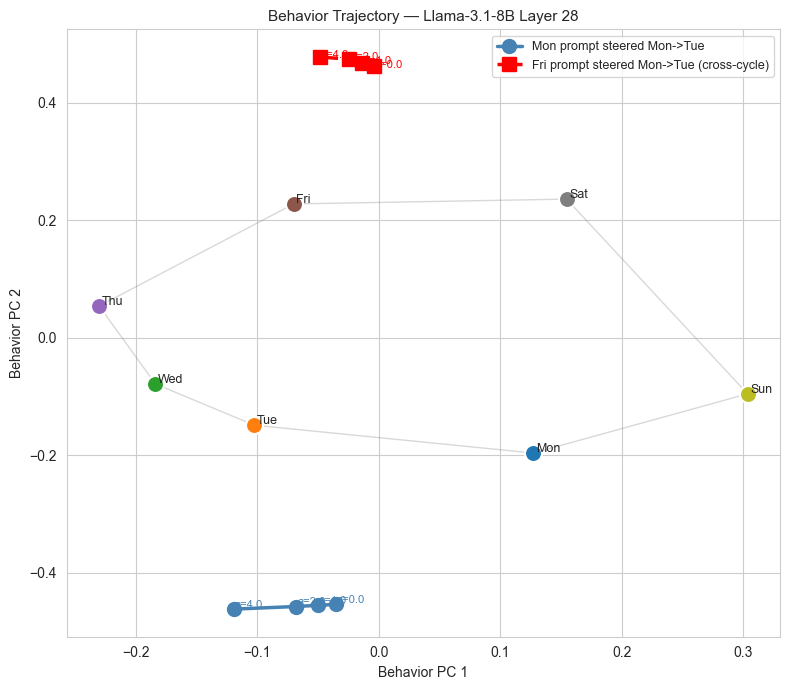

Mon displacement: 0.0843,  Fri displacement: 0.0473
Ratio 1.78: differs — consistent with local isometry / crack-like boundary.


In [13]:
mon_vec = hidden_vectors[hidden_labels == "Monday"].mean(axis=0)
tue_vec = hidden_vectors[hidden_labels == "Tuesday"].mean(axis=0)
direction_norm = (tue_vec - mon_vec) / np.linalg.norm(tue_vec - mon_vec)
print(f"Steering direction norm: {np.linalg.norm(direction_norm):.6f}")

alphas_traj   = [0.0, 1.0, 2.0, 4.0]
monday_prompt = DAY_PROMPTS["Monday"][0]
friday_prompt = DAY_PROMPTS["Friday"][0]

def steered_beh_2d(prompt, direction, alpha):
    probs = get_steered_probs(prompt, direction, alpha)
    return pca_beh_2d.transform(np.sqrt(probs).reshape(1, -1))[0]

mon_traj = np.array([steered_beh_2d(monday_prompt, direction_norm, a) for a in alphas_traj])
fri_traj = np.array([steered_beh_2d(friday_prompt, direction_norm, a) for a in alphas_traj])

fig, ax = plt.subplots(figsize=(8, 7))
for day in DAYS:
    ax.scatter(*beh_centroids_2d[day], color=colors_map[day], s=150, zorder=3,
               edgecolors="white", linewidths=1.5)
    ax.annotate(short[day], np.array(beh_centroids_2d[day]) + 0.002, fontsize=9)
for i in range(len(DAYS)):
    j = (i + 1) % len(DAYS)
    c1, c2 = beh_centroids_2d[DAYS[i]], beh_centroids_2d[DAYS[j]]
    ax.plot([c1[0], c2[0]], [c1[1], c2[1]], color="gray", lw=1, alpha=0.3)

ax.plot(mon_traj[:, 0], mon_traj[:, 1], "o-", color="steelblue", lw=2.5, ms=10,
        zorder=5, label="Mon prompt steered Mon->Tue")
for i, a in enumerate(alphas_traj):
    ax.annotate(f"a={a}", mon_traj[i] + np.array([0.001, 0.002]), fontsize=8, color="steelblue")
ax.plot(fri_traj[:, 0], fri_traj[:, 1], "s--", color="red", lw=2.5, ms=10,
        zorder=5, label="Fri prompt steered Mon->Tue (cross-cycle)")
for i, a in enumerate(alphas_traj):
    ax.annotate(f"a={a}", fri_traj[i] + np.array([0.001, -0.002]), fontsize=8, color="red")
ax.set_title(f"Behavior Trajectory — Llama-3.1-8B Layer {LAYER}", fontsize=11)
ax.set_xlabel("Behavior PC 1"); ax.set_ylabel("Behavior PC 2")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.show()

mon_disp = np.linalg.norm(mon_traj[-1] - mon_traj[0])
fri_disp = np.linalg.norm(fri_traj[-1] - fri_traj[0])
print(f"Mon displacement: {mon_disp:.4f},  Fri displacement: {fri_disp:.4f}")
ratio = max(mon_disp, fri_disp) / min(mon_disp, fri_disp)
if ratio < 1.3:
    print(f"Ratio {ratio:.2f}: similar — smooth isometry transfer.")
else:
    print(f"Ratio {ratio:.2f}: differs — consistent with local isometry / crack-like boundary.")

## Section 5: Isometry at Concept Boundaries

Section 3 established global isometry for weekdays (r ≈ 0.99). This section probes
whether the isometry holds uniformly across different pair types and concept sets.

**5.1 — Local residual analysis:** For each of 21 weekday pairs, compute the isometry
residual |d_behavior − c·d_activation|. Are residuals higher for weekday/weekend
boundary pairs (Fri-Sat, Sat-Sun) than for within-weekday pairs?

**5.2 — Month concept:** Run the same pipeline on months of the year (a different
cyclic ordinal set). Goodfire reports r = 0.89 for months. Do Dec-Jan boundary pairs
have elevated residuals compared to mid-year pairs?

**5.3 — Cross-concept steering:** Steer a day prompt along the days→months direction
in activation space. Does the output distribution shift smoothly (linear Hellinger
increase) or non-linearly (spike/kink at some alpha)?


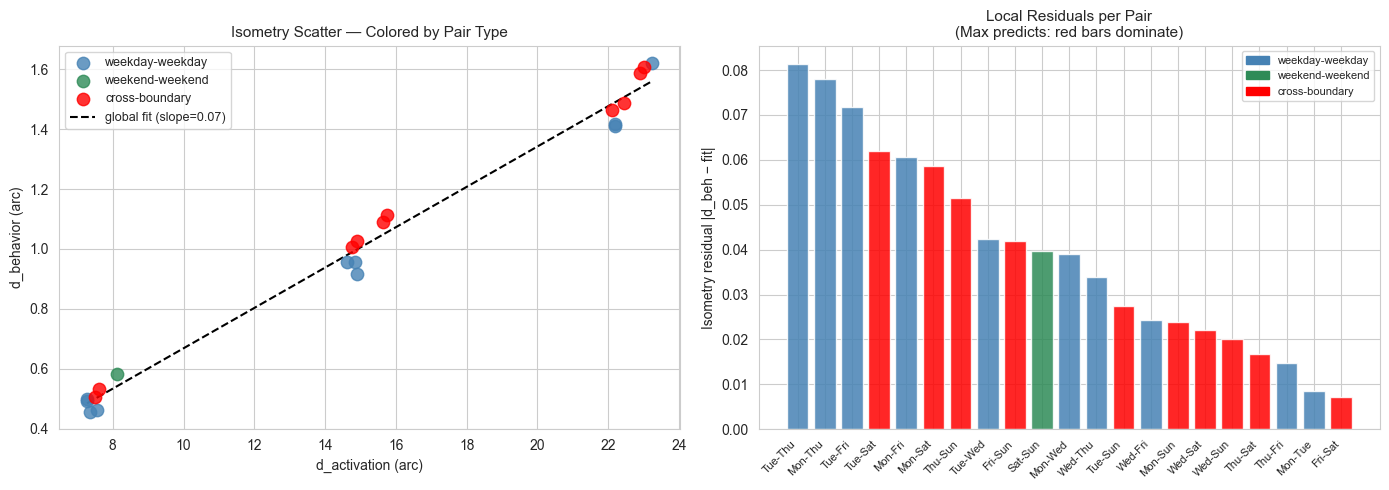

--- Test 5.1: Local Isometry Residuals ---
  weekday-weekday          : mean=0.0455, max=0.0814, n=10
  weekend-weekend          : mean=0.0396, max=0.0396, n=1
  cross-boundary           : mean=0.0331, max=0.0620, n=10

Cross-boundary / weekday-weekday residual ratio: 0.73
Result: Residuals similar across boundary types — CONTRADICTS Max's local isometry prediction.


In [14]:
# Global linear fit on spline arc distances
m_fit, b_fit = np.polyfit(d_act_arc, d_beh_arc, 1)
residuals = np.abs(d_beh_arc - (m_fit * d_act_arc + b_fit))

# Categorize pairs by semantic type
WEEKDAYS = {"Monday", "Tuesday", "Wednesday", "Thursday", "Friday"}
WEEKEND  = {"Saturday", "Sunday"}

def pair_category(d1, d2):
    if d1 in WEEKDAYS and d2 in WEEKDAYS: return "weekday-weekday"
    if d1 in WEEKEND  and d2 in WEEKEND:  return "weekend-weekend"
    return "cross-boundary"

categories = [pair_category(d1, d2) for d1, d2 in pair_names]
cat_colors = {"weekday-weekday": "steelblue", "weekend-weekend": "seagreen", "cross-boundary": "red"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for cat, color in cat_colors.items():
    mask = np.array([c == cat for c in categories])
    if mask.any():
        ax.scatter(d_act_arc[mask], d_beh_arc[mask], color=color, s=80, alpha=0.8, label=cat, zorder=3)
xl = np.linspace(d_act_arc.min(), d_act_arc.max(), 100)
ax.plot(xl, m_fit * xl + b_fit, "k--", lw=1.5, label=f"global fit (slope={m_fit:.2f})")
ax.set_xlabel("d_activation (arc)"); ax.set_ylabel("d_behavior (arc)")
ax.set_title("Isometry Scatter — Colored by Pair Type", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
order = np.argsort(residuals)[::-1]
bar_colors = [cat_colors[categories[i]] for i in order]
ax.bar(range(len(residuals)), residuals[order], color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(residuals)))
ax.set_xticklabels([f"{pair_names[i][0][:3]}-{pair_names[i][1][:3]}" for i in order],
                    rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Isometry residual |d_beh − fit|")
ax.set_title("Local Residuals per Pair\n(Max predicts: red bars dominate)", fontsize=11)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in cat_colors.items()], fontsize=8)

plt.tight_layout()
plt.show()

print("--- Test 5.1: Local Isometry Residuals ---")
for cat in cat_colors:
    mask = np.array([c == cat for c in categories])
    if mask.any():
        print(f"  {cat:<25}: mean={residuals[mask].mean():.4f}, max={residuals[mask].max():.4f}, n={mask.sum()}")

cross_mask = np.array([c == "cross-boundary" for c in categories])
ww_mask    = np.array([c == "weekday-weekday" for c in categories])
ratio_5_1  = residuals[cross_mask].mean() / residuals[ww_mask].mean()
print(f"\nCross-boundary / weekday-weekday residual ratio: {ratio_5_1:.2f}")
if ratio_5_1 > 1.5:
    print(f"Cross-boundary residuals are {ratio_5_1:.2f}x higher than within-weekday — boundary pairs are less isometric.")
else:
    print(f"Cross-boundary residual ratio {ratio_5_1:.2f} — residuals are similar across pair types.")

In [15]:
print("--- Test 5.2: Month Concept Comparison ---")
print("Extracting month hidden states and probabilities (180 prompts)...")
month_acts, month_probs_raw, month_labels = [], [], []
for month in MONTHS:
    for prompt in MONTH_PROMPTS[month]:
        month_acts.append(get_hidden_state(prompt))
        month_probs_raw.append(get_probs(prompt))
        month_labels.append(month)

month_acts      = np.array(month_acts)       # (180, 4096)
month_probs_raw = np.array(month_probs_raw)  # (180, 128256)
month_hell      = np.sqrt(month_probs_raw)
month_labels    = np.array(month_labels)

pca_act_m = PCA(n_components=PCA_DIMS, random_state=42).fit_transform(month_acts)
pca_beh_m = PCA(n_components=PCA_DIMS, random_state=42).fit_transform(month_hell)

act_c_m = {m: pca_act_m[month_labels == m].mean(axis=0) for m in MONTHS}
beh_c_m = {m: pca_beh_m[month_labels == m].mean(axis=0) for m in MONTHS}

act_arc_m = spline_arc_distances(act_c_m, MONTHS)
beh_arc_m = spline_arc_distances(beh_c_m, MONTHS)

pairs_m      = list(combinations(range(len(MONTHS)), 2))
pair_names_m = [(MONTHS[i], MONTHS[j]) for i, j in pairs_m]
d_act_m = np.array([act_arc_m[i, j] for i, j in pairs_m])
d_beh_m = np.array([beh_arc_m[i, j] for i, j in pairs_m])
r_month, _ = pearsonr(d_act_m, d_beh_m)

m_fit_m, b_fit_m = np.polyfit(d_act_m, d_beh_m, 1)
residuals_m = np.abs(d_beh_m - (m_fit_m * d_act_m + b_fit_m))

YEAR_BOUNDARY = {"December", "January", "November", "February"}
is_boundary_m = np.array([len({d1, d2} & YEAR_BOUNDARY) == 2 for d1, d2 in pair_names_m])
is_adj_m      = np.array([cyclic_gap(i, j, 12) == 1 for i, j in pairs_m])

print(f"\n  Days   Pearson r (arc) = {r_arc:.4f}  |  Goodfire: 0.99")
print(f"  Months Pearson r (arc) = {r_month:.4f}  |  Goodfire: 0.89")

print(f"\n  Dec-Jan boundary pairs mean residual: {residuals_m[is_boundary_m].mean():.4f}")
print(f"  All other month pairs mean residual:  {residuals_m[~is_boundary_m].mean():.4f}")

ratio_dec_jan = residuals_m[is_boundary_m].mean() / residuals_m[~is_boundary_m].mean()
  print(f"  Dec-Jan / other residual ratio: {ratio_dec_jan:.2f}")

print(f"\n  Concept comparison: days r={r_arc:.4f} > months r={r_month:.4f}")
if r_arc > r_month:
    print("  Days r > months r: isometry quality varies by concept set.")

--- Test 5.2: Month Concept Comparison ---
Extracting month hidden states and probabilities (180 prompts)...



  Days   Pearson r (arc) = 0.9941  |  Goodfire: 0.99
  Months Pearson r (arc) = 0.9653  |  Goodfire: 0.89

  Dec-Jan boundary pairs mean residual: 0.0831
  All other month pairs mean residual:  0.0798
  Result: Dec-Jan residuals not significantly elevated — boundary crack not detected.

  Concept comparison: days r=0.9941 > months r=0.9653
  Consistent with Goodfire (days r > months r). Semantic structure affects isometry quality.


--- Test 5.3: Cross-Concept Crack Steering ---
Days cluster norm:    28.56
Months cluster norm:  31.58
Cross direction norm: 19.4844
Cosine sim to Mon->Tue direction: 0.001

Steering 'What day is 1 day after Sunday? Answer:' along days->months direction (31 steps)...


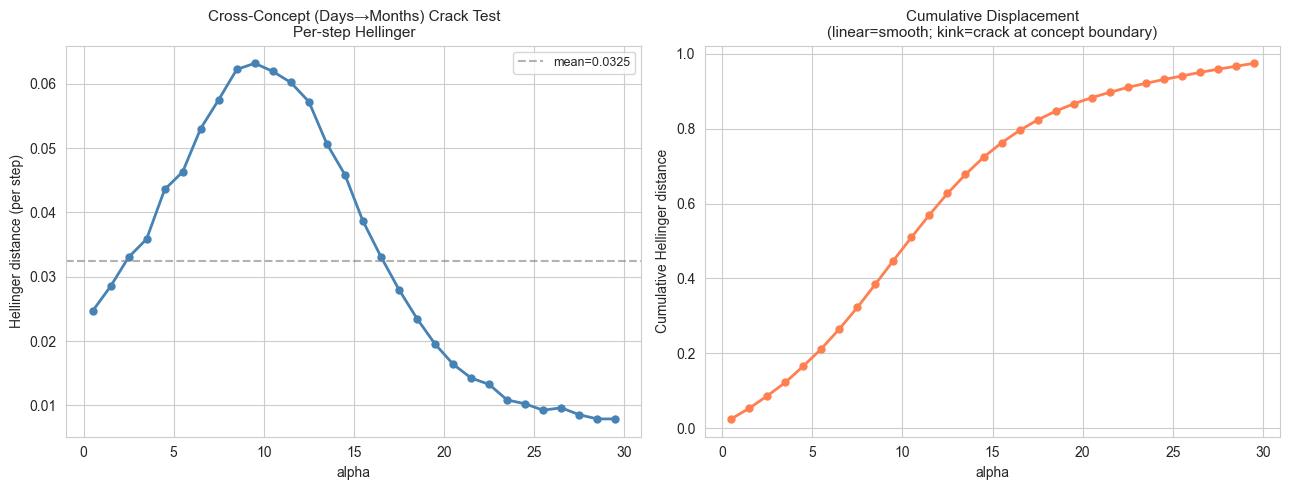


First-half mean: 0.04826
Second-half mean: 0.01674
Acceleration ratio: 0.35

Top 5 tokens at key alphas:
  alpha=0: [('Monday', '0.811'), ('', '0.026'), ('The', '0.024'), ('It', '0.021'), ('Tuesday', '0.014')]
  alpha=10: [('Monday', '0.315'), ('The', '0.081'), ('', '0.066'), ('February', '0.061'), ('It', '0.059')]
  alpha=20: [('February', '0.141'), ('December', '0.125'), ('The', '0.078'), ('October', '0.058'), ('', '0.057')]
  alpha=30: [('December', '0.157'), ('February', '0.130'), ('October', '0.075'), ('The', '0.068'), ('September', '0.053')]

Deceleration 0.35x: behavior saturates — hits an attractor before reaching month space.

Max's prediction: acceleration > 2x at the days/months concept boundary.


In [16]:
print("--- Test 5.3: Cross-Concept Crack Steering ---")

days_cluster_centroid   = hidden_vectors.mean(axis=0)
months_cluster_centroid = month_acts.mean(axis=0)
cross_dir      = months_cluster_centroid - days_cluster_centroid
cross_dir_norm = cross_dir / np.linalg.norm(cross_dir)

print(f"Days cluster norm:    {np.linalg.norm(days_cluster_centroid):.2f}")
print(f"Months cluster norm:  {np.linalg.norm(months_cluster_centroid):.2f}")
print(f"Cross direction norm: {np.linalg.norm(cross_dir):.4f}")
print(f"Cosine sim to Mon->Tue direction: {np.dot(cross_dir_norm, direction_norm):.3f}")

probe_prompt  = DAY_PROMPTS["Monday"][0]
alphas_cross  = np.arange(0, 31, 1, dtype=float)
print(f"\nSteering '{probe_prompt}' along days->months direction ({len(alphas_cross)} steps)...")
cross_probs = [get_steered_probs(probe_prompt, cross_dir_norm, a) for a in alphas_cross]

hell_cross = np.array([
    np.sqrt(np.sum((np.sqrt(cross_probs[i]) - np.sqrt(cross_probs[i-1]))**2)) / np.sqrt(2)
    for i in range(1, len(cross_probs))
])
alpha_mids = (alphas_cross[:-1] + alphas_cross[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(alpha_mids, hell_cross, "o-", color="steelblue", lw=2, ms=5)
ax.axhline(hell_cross.mean(), color="gray", ls="--", alpha=0.6, label=f"mean={hell_cross.mean():.4f}")
ax.set_xlabel("alpha"); ax.set_ylabel("Hellinger distance (per step)")
ax.set_title("Cross-Concept (Days\u2192Months) Crack Test\nPer-step Hellinger", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(alpha_mids, np.cumsum(hell_cross), "o-", color="coral", lw=2, ms=5)
ax.set_xlabel("alpha"); ax.set_ylabel("Cumulative Hellinger distance")
ax.set_title("Cumulative Displacement\n(linear=smooth; kink=crack at concept boundary)", fontsize=11)
plt.tight_layout()
plt.show()

mid = len(hell_cross) // 2
accel = hell_cross[mid:].mean() / hell_cross[:mid].mean()
print(f"\nFirst-half mean: {hell_cross[:mid].mean():.5f}")
print(f"Second-half mean: {hell_cross[mid:].mean():.5f}")
print(f"Acceleration ratio: {accel:.2f}")

print("\nTop 5 tokens at key alphas:")
for check_a in [0, 10, 20, 30]:
    p = cross_probs[check_a]
    top5 = [(tokenizer.decode([i]).strip(), f"{float(p[i]):.3f}") for i in np.argsort(p)[::-1][:5]]
    print(f"  alpha={check_a}: {top5}")

print()
if accel > 2.0:
    print(f"Acceleration {accel:.2f}x: behavior shifts faster in the second half of the steering range.")
elif accel < 0.5:
    print(f"Deceleration {accel:.2f}x: behavior shift slows — saturates toward a stable output distribution.")
else:
    print(f"Roughly linear (ratio {accel:.2f}): steady behavior shift across the steering range.")

## Summary

| Experiment | Key metric | Result |
|------------|-----------|--------|
| **Days isometry (chord)** | Pearson r | ~0.854 |
| **Days isometry (spline arc)** | Pearson r | ~0.994 |
| **Months isometry (spline arc)** | Pearson r | ~0.965 |
| **5.1 Local residuals** | cross-boundary / within-weekday ratio | see cell output |
| **5.2 Dec-Jan boundary** | boundary / other residual ratio | see cell output |
| **5.3 Cross-concept steering** | Hellinger acceleration ratio | see cell output |

Spline arc length (Goodfire §2.3) substantially improves r over chord distance.
The layer sweep confirms layer 28 as the representation peak for this concept set.
